In [ ]:
# Primero, asegurese de cargar el archivo de trabajo de este Notebook:
# ideam-dhime_Olaya-Herrera_pcp_mon_1991-2023.csv

In [1]:
# Cargar algunas liberías y herramientas
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
# Nombre de archivo de entrada
ifile = "ideam-dhime_Olaya-Herrera_pcp_mon_1991-2023.csv"

In [3]:
# Leer archivo, en este caso con el método read_csv de la librería pandas (pd)
df1=pd.read_csv(ifile)

In [4]:
# Hacer un dataframe sólo con las fechas y el valor de la pcp:
df =  pd.DataFrame({'date' : df1.Fecha, 'pcp' : df1.Valor})

In [5]:
# Para convertir las fechas de entrada de strings a a un objeto datetime64:
df.date = pd.to_datetime(df.date)
yrs = df.date.dt.year

In [6]:
df

,date,pcp
0,1991-01-01,47.6
1,1991-02-01,30.5
2,1991-03-01,255.0
3,1991-04-01,140.2
4,1991-05-01,172.0
...,...,...
391,2023-08-01,59.8
392,2023-09-01,100.0
393,2023-10-01,171.2
394,2023-11-01,101.1


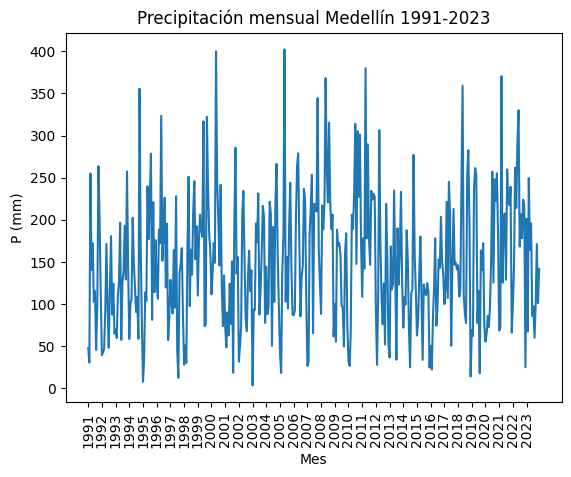

In [7]:
# Ahora graficamos la serie de tiempo
ini=0
fnl=len(df)#23
dix=12
plt.plot(df.date[ini:fnl],df.pcp[ini:fnl])
plt.title("Precipitación mensual Medellín 1991-2023")
plt.xlabel("Mes")
plt.xticks(df.date[ini:fnl:dix],yrs[ini:fnl:dix], rotation='vertical')
plt.ylabel("P (mm)")
plt.show()

In [8]:
# Graficar algún periodo en particular, e.g. 2009-2012
# 2009-2012 - La Niña 2010-2011
fini = "2009-01-01" # Esta fecha quedará incluida
ffnl = "2012-12-31" #
dfsel = df.loc[(df['date'] >= fini) & (df['date'] < ffnl)]

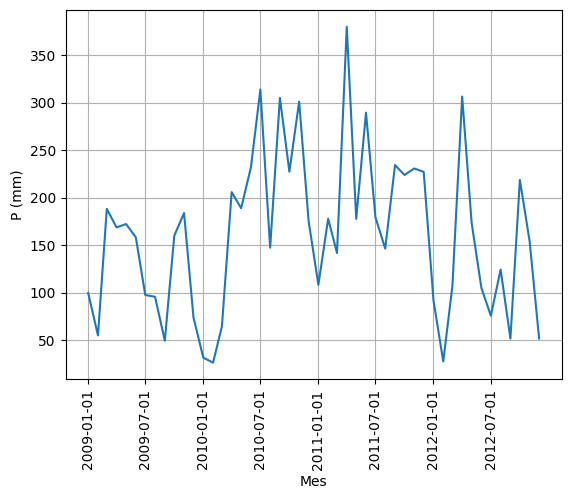

In [9]:
plt.plot(dfsel.date,dfsel.pcp)
plt.xlabel("Mes")
plt.xticks(dfsel.date[::6], rotation='vertical')
plt.grid()
plt.ylabel("P (mm)")
plt.show()

In [10]:
# Calculando el ciclo anual: agrupamos por month
xancy=df.groupby(df.date.dt.month)['pcp'].mean()

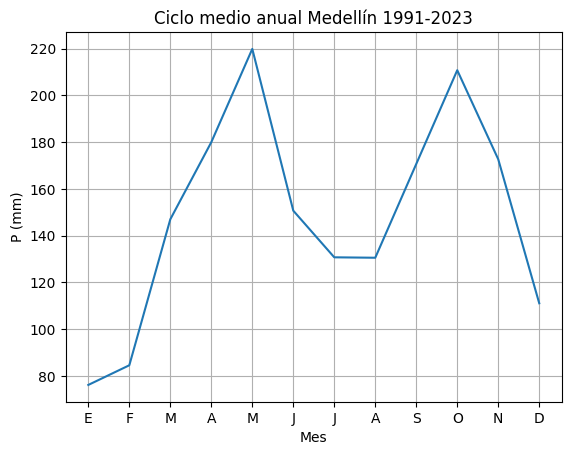

In [11]:
# Graficando ciclo anual:
moncy=["E","F","M","A","M","J","J","A","S","O","N","D"]
monids=np.arange(1,13,1)
plt.plot(xancy)
plt.xlabel("Mes")
plt.xticks(monids,moncy,rotation='horizontal')
plt.ylabel("P (mm)")
plt.title("Ciclo medio anual Medellín 1991-2023")
plt.grid()
plt.show()

In [ ]:
# Extrayendo algunos años particulares, como 1997, 2011 y 2015

# 1997 - El Niño
fini = "1997-01-01" # Esta fecha quedará incluida
ffnl = "1997-12-31" #
df97 = df.loc[(df['date'] >= fini) & (df['date'] < ffnl)]
y1997=df97.pcp.values

# 2011 - La Niña
fini = "2011-01-01" # Esta fecha quedará incluida
ffnl = "2011-12-31" #
df11 = df.loc[(df['date'] >= fini) & (df['date'] < ffnl)]
y2011=df11.pcp.values

# 2015 - El Niño
fini = "2015-01-01" # Esta fecha quedará incluida
ffnl = "2015-12-31" #
df15 = df.loc[(df['date'] >= fini) & (df['date'] < ffnl)]
y2015=df15.pcp.values


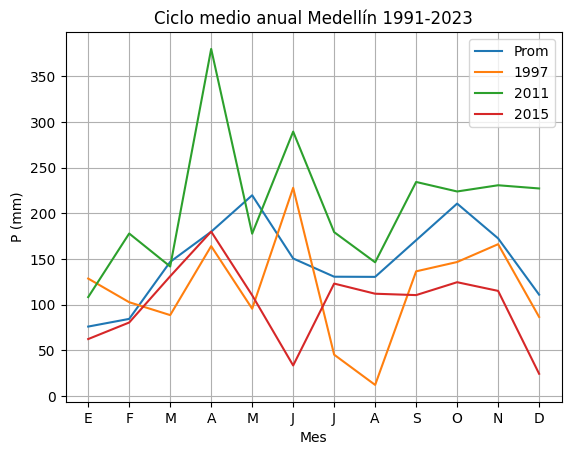

In [ ]:
# Comparando varios años específicos y ciclo medio anual:
mons=["E","F","M","A","M","J","J","A","S","O","N","D"]
moni=np.arange(0,12,1) # indices para los meses
plt.plot(xancy.values)     # Nos quedamos sólo con los valores, sin tiempo.
plt.plot(y1997)
plt.plot(y2011)
plt.plot(y2015)
plt.legend(["Prom","1997","2011","2015"],loc=1)
plt.xlabel("Mes")
plt.xticks(moni,mons,rotation='horizontal')
plt.grid()
plt.ylabel("P (mm)")
plt.title("Ciclo medio anual Medellín 1991-2023")
plt.show()

In [ ]:
# Calculando las anomalías "manualmente"

# Primero tomar sólo los valores numéricos de interés:
x = df.pcp.values

# Creando un arreglo de ciclos anuales repetidos para luego
# calcular las anomalías ...
xancyr=np.zeros(len(x))
nyrs=int(len(x)/12)
for i in range(nyrs):
    ki=i*12
    kf=ki+12
    xancyr[ki:kf]=xancy

# Calculando las anomalías:
xans = x - xancyr
dfans = pd.DataFrame({'date' : df.date, 'pcpans' : xans})


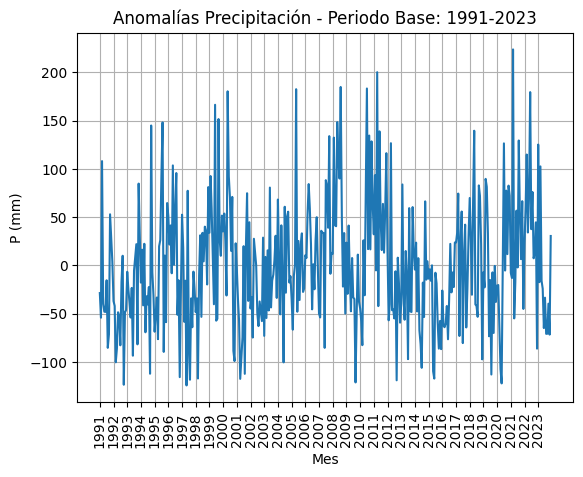

In [ ]:
# Ahora graficamos la serie de tiempo de las precipitaciones
plt.plot(dfans.date,dfans.pcpans)
plt.title("Anomalías Precipitación - Periodo Base: 1991-2023")
plt.xlabel("Tiempo")
plt.ylabel("P (mm)")
plt.xlabel("Mes")
plt.xticks(dfans.date[ini:fnl:dix],yrs[ini:fnl:dix], rotation='vertical')
plt.grid()
plt.show()


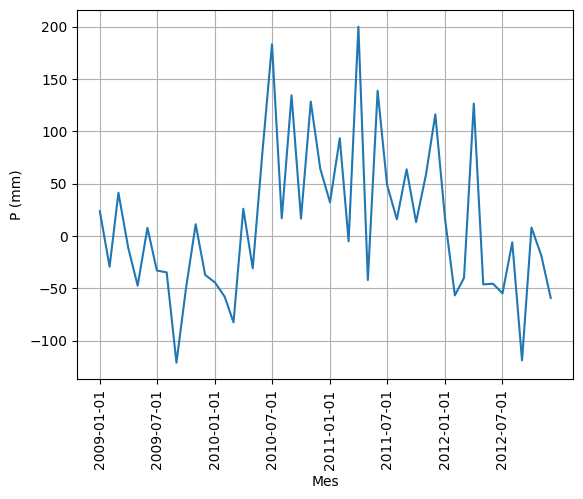

In [ ]:
# Graficar algún periodo en particular, e.g. 2009-2012
# 2009-2012 - La Niña 2010-2011
fini = "2009-01-01" # Esta fecha quedará incluida
ffnl = "2012-12-31" #
dfanssel = dfans.loc[(dfans['date'] >= fini) & (dfans['date'] < ffnl)]

plt.plot(dfanssel.date,dfanssel.pcpans)
plt.xlabel("Mes")
plt.xticks(dfanssel.date[::6], rotation='vertical')
plt.grid()
plt.ylabel("P (mm)")
plt.show()